In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [3]:
# ------------------------------------------------------------
# 1. PROBLEME MACHINE LEARNING
# ------------------------------------------------------------
# On cherche à apprendre une relation non linéaire entre :
#
# Entrées :
# - heures d'étude
# - sommeil
# - stress
# - participation
# - sport
# - écran
#
# Sortie :
# - note finale / 20
#
# On utilise une régression polynomiale :
# sklearn va automatiquement créer les puissances des variables.
# ------------------------------------------------------------



In [4]:
# ------------------------------------------------------------
# 2. DATASET
# ------------------------------------------------------------
heures_etude  = np.array([2, 4, 6, 8, 10, 3, 7])
sommeil       = np.array([5, 6, 7, 7, 8, 4, 6])
stress        = np.array([8, 6, 5, 4, 3, 9, 5])
participation = np.array([20, 40, 60, 80, 90, 30, 70])
sport         = np.array([0, 2, 3, 4, 5, 0, 3])
ecran         = np.array([6, 5, 4, 3, 2, 7, 4])

y = np.array([10, 13, 15, 17, 18.5, 11, 16])



In [5]:
# ------------------------------------------------------------
# 3. MATRICE DES FEATURES (X)
# ------------------------------------------------------------
# Chaque ligne = un étudiant
# Chaque colonne = une variable explicative

X = np.column_stack([
    heures_etude,
    sommeil,
    stress,
    participation,
    sport,
    ecran
])



In [6]:
# ------------------------------------------------------------
# 4. TRANSFORMATION POLYNOMIALE
# ------------------------------------------------------------
# On transforme automatiquement les variables :
# x -> x, x², x³, ... jusqu'au degré choisi

degree = 3  # degré du polynôme (modifiable)

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)




In [7]:
# ------------------------------------------------------------
# 5. ENTRAINEMENT DU MODELE
# ------------------------------------------------------------
# Régression linéaire sur les variables transformées

model = LinearRegression()
model.fit(X_poly, y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



--- SAISIE UTILISATEUR ---

--- RESULTAT ---
Note prédite : 11.80 / 20


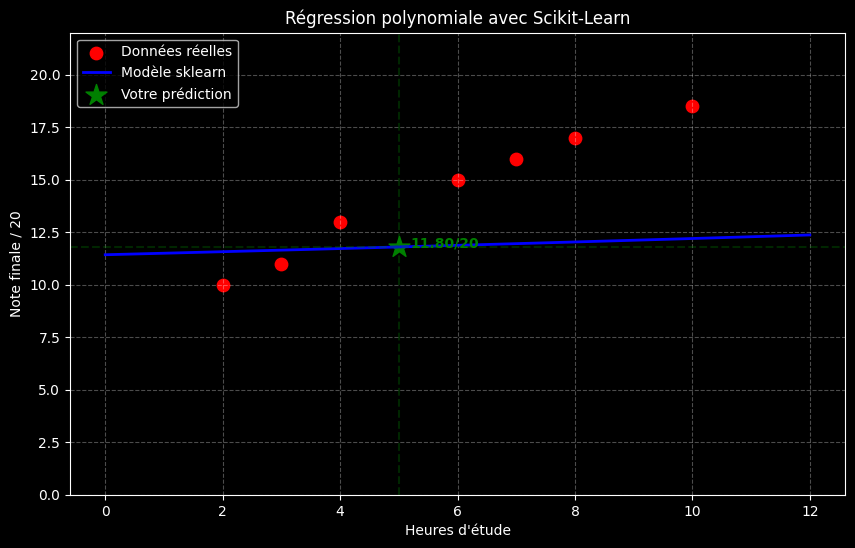

In [8]:
# ------------------------------------------------------------
# 6. SAISIE UTILISATEUR
# ------------------------------------------------------------
print("\n--- SAISIE UTILISATEUR ---")

u1 = float(input("Heures d'étude : "))
u2 = float(input("Heures de sommeil : "))
u3 = float(input("Niveau de stress : "))
u4 = float(input("Participation (%) : "))
u5 = float(input("Heures de sport : "))
u6 = float(input("Heures d'écran : "))


# ------------------------------------------------------------
# 7. PREDICTION UTILISATEUR
# ------------------------------------------------------------
user_input = np.array([[u1, u2, u3, u4, u5, u6]])

user_poly = poly.transform(user_input)
prediction = model.predict(user_poly)[0]


# ------------------------------------------------------------
# 8. VISUALISATION (PROJECTION SUR HEURES D'ETUDE)
# ------------------------------------------------------------
# On fixe les autres variables et on fait varier uniquement
# les heures d'étude pour voir l'effet sur la note

x_line = np.linspace(0, 12, 100)
y_line = []

for h in x_line:
    temp_input = np.array([[h, u2, u3, u4, u5, u6]])
    temp_poly = poly.transform(temp_input)
    y_line.append(model.predict(temp_poly)[0])


# ------------------------------------------------------------
# 9. AFFICHAGE GRAPHIQUE
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Dataset réel
plt.scatter(heures_etude, y, color='red', s=80, label="Données réelles")

# Courbe du modèle
plt.plot(x_line, y_line, color='blue', linewidth=2, label="Modèle sklearn")

# Point utilisateur
plt.scatter(u1, prediction, color='green', marker='*', s=250,
            label="Votre prédiction")

plt.axvline(u1, linestyle="--", color='green', alpha=0.3)
plt.axhline(prediction, linestyle="--", color='green', alpha=0.3)

plt.text(u1 + 0.2, prediction,
         f"{prediction:.2f}/20",
         color='green', fontweight='bold')

plt.title("Régression polynomiale avec Scikit-Learn")
plt.xlabel("Heures d'étude")
plt.ylabel("Note finale / 20")
plt.ylim(0, 22)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

# ------------------------------------------------------------
# 10. RESULTAT
# ------------------------------------------------------------
print("\n--- RESULTAT ---")
print(f"Note prédite : {prediction:.2f} / 20")

plt.show()